# Netflix Dataset - Exploratory Data Analysis (EDA)

This project performs Exploratory Data Analysis (EDA) on the Netflix dataset to understand patterns in Netflix content.

Objectives:
- Understand the distribution of Movies and TV Shows
- Identify the most common genres
- Analyze content growth over the years
- Find the top countries producing Netflix content
- Study content ratings and durations

Tools Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## 📊 Dataset Overview

| Feature | Description |
|-------|-------------|
| show_id | Unique ID for each title |
| type | Movie or TV Show |
| title | Title of the content |
| director | Director of the title |
| cast | Main actors |
| country | Country of production |
| date_added | Date added to Netflix |
| release_year | Year the title was released |
| rating | Content rating |
| duration | Duration of movie or seasons |
| listed_in | Genre/category |
| description | Short description |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Load Dataset

In [2]:
df = pd.read_csv(r"../dataset/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

### Check Columns Names

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

# 2. Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
# remove spaces
df['date_added'] = df['date_added'].str.strip()

# convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# drop invalid dates
df.dropna(subset=['date_added'], inplace=True)

In [8]:
df['year_added'] = df['date_added'].dt.year

In [9]:
df['month_added'] = df['date_added'].dt.month

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

### Strip unnecessary spaces.

In [12]:
df['country'] = df['country'].str.strip()

# 3. Missing Values Analysis

In [14]:
#Check Missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2624
cast             825
country          830
date_added         0
release_year       0
rating             4
duration           3
listed_in          0
description        0
year_added         0
month_added        0
dtype: int64

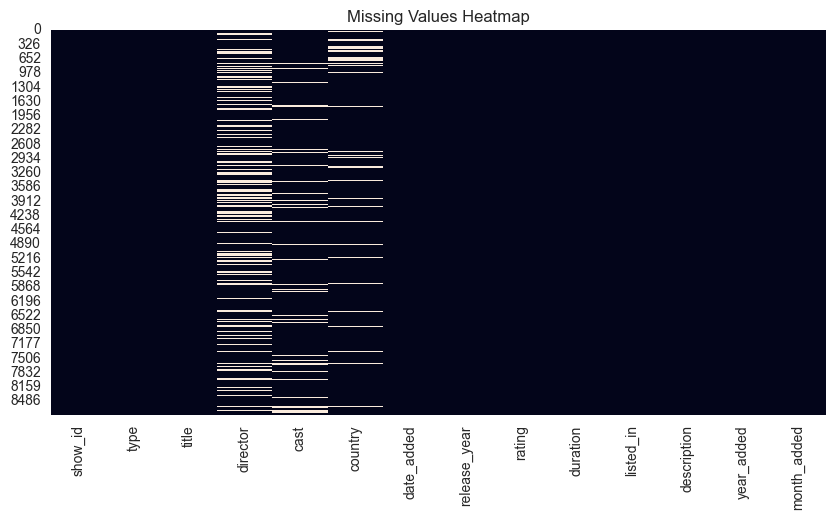

In [15]:
#Visualize Missing Values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [16]:
#Fill missing director values
df['director'].fillna('Unknown', inplace=True)

C:\Users\SAURABH ANAND\AppData\Local\Temp\ipykernel_21540\762213685.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)


In [18]:
#Fill missing cast
df['cast'] = df['cast'].fillna('Unknown')

In [19]:
#Fill missing country
df['country'] = df['country'].fillna('Unknown')

In [20]:
#drop rows where date_added is missing
df.dropna(subset=['date_added'], inplace=True)

# 4. Univariate Analysis

In [21]:
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

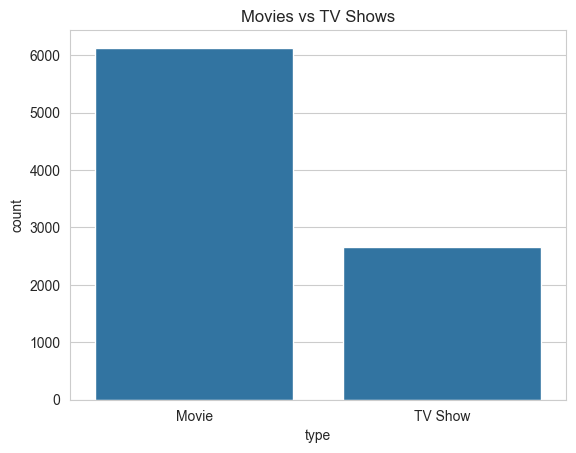

In [22]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

In [23]:
#Content Ratings
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

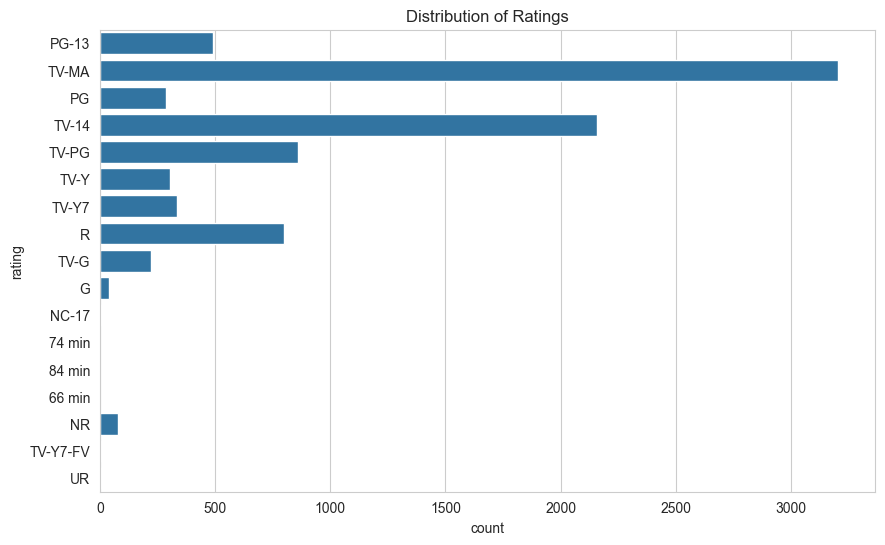

In [24]:
plt.figure(figsize=(10,6))
sns.countplot(y='rating', data=df)
plt.title("Distribution of Ratings")
plt.show()

In [25]:
#Content Realease by Year
df['release_year'].value_counts()

release_year
2018    1146
2017    1032
2019    1030
2020     953
2016     901
        ... 
1961       1
1925       1
1959       1
1966       1
1947       1
Name: count, Length: 74, dtype: int64

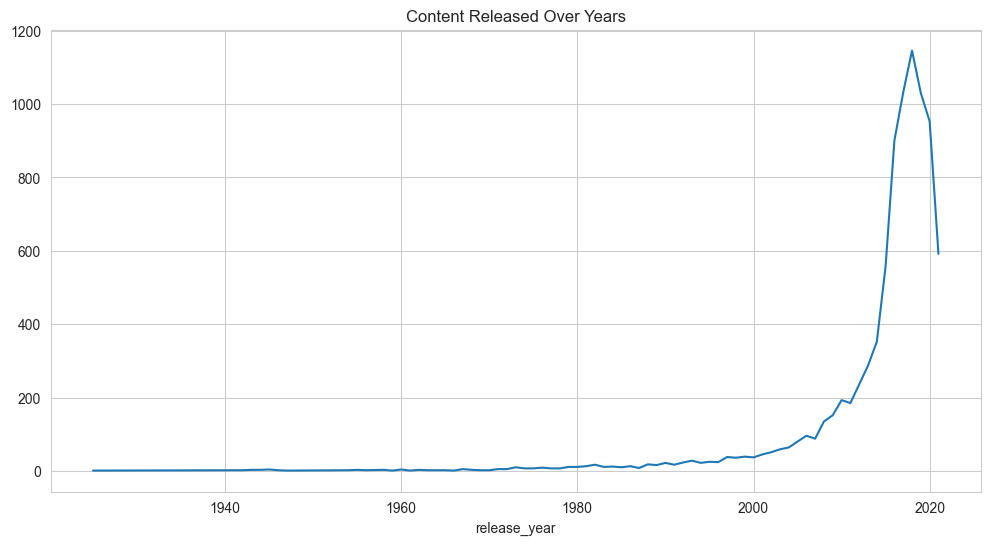

In [26]:
plt.figure(figsize=(12,6))
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Released Over Years")
plt.show()

In [27]:
#Top Generes
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

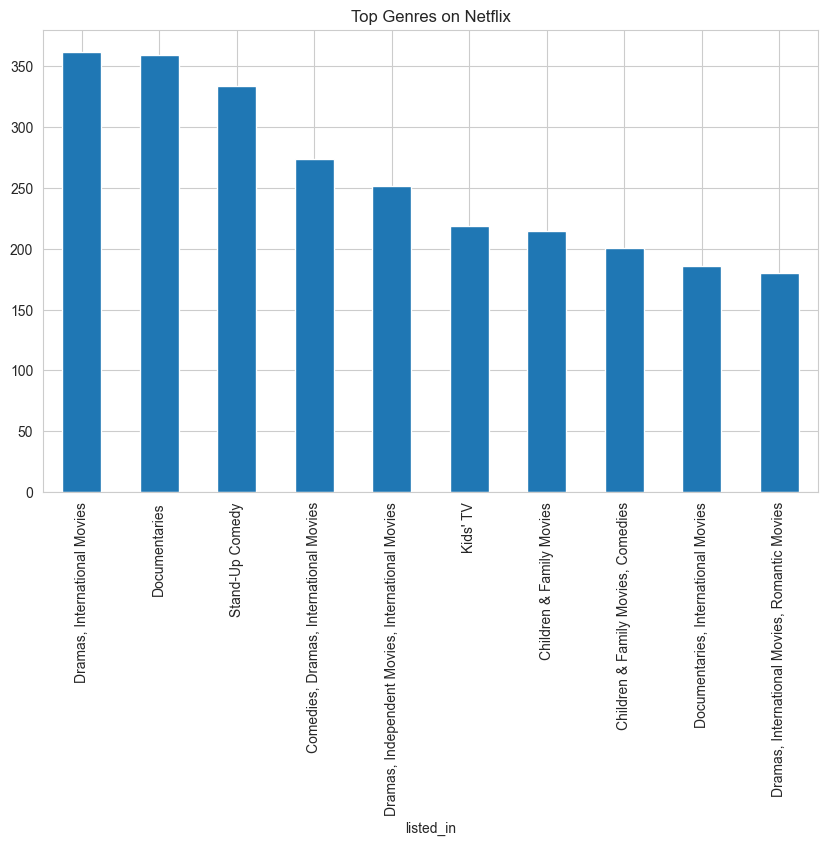

In [28]:
plt.figure(figsize=(10,6))
df['listed_in'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.show()

# 5. Bivariate Analysis

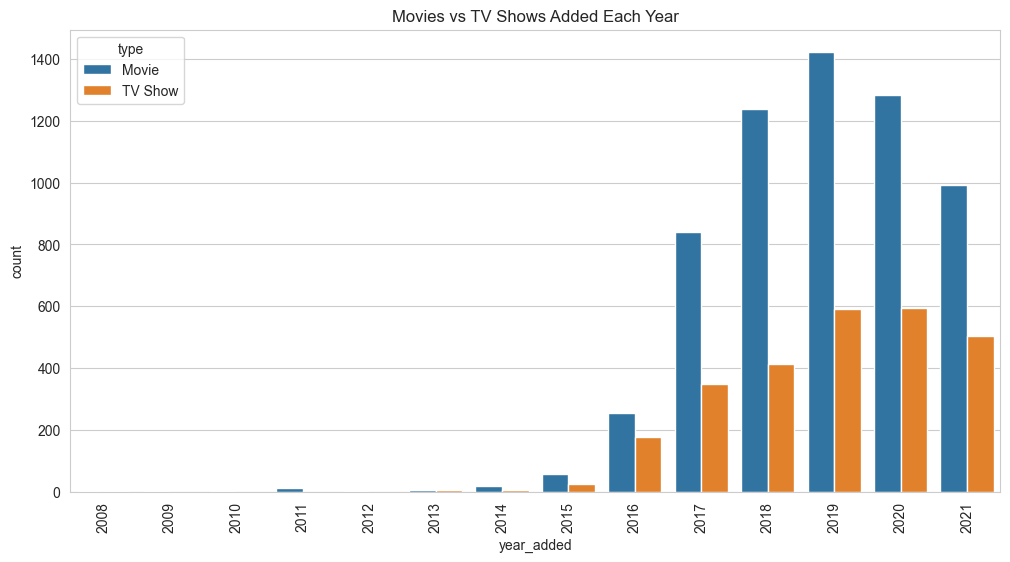

In [29]:
#Movies vs TV shows by year
plt.figure(figsize=(12,6))
sns.countplot(x='year_added', hue='type', data=df)
plt.xticks(rotation=90)
plt.title("Movies vs TV Shows Added Each Year")
plt.show()

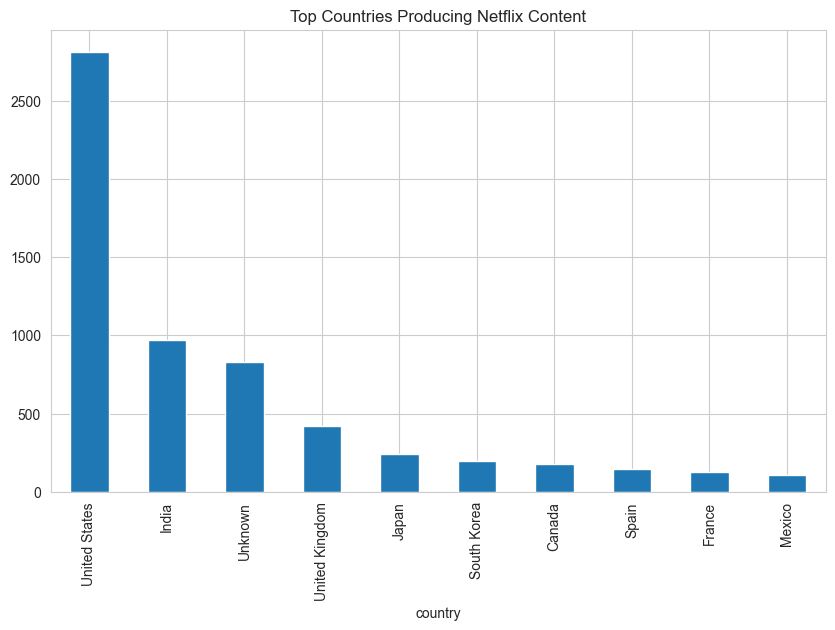

In [30]:
#Content by country
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_countries.plot(kind='bar')
plt.title("Top Countries Producing Netflix Content")
plt.show()

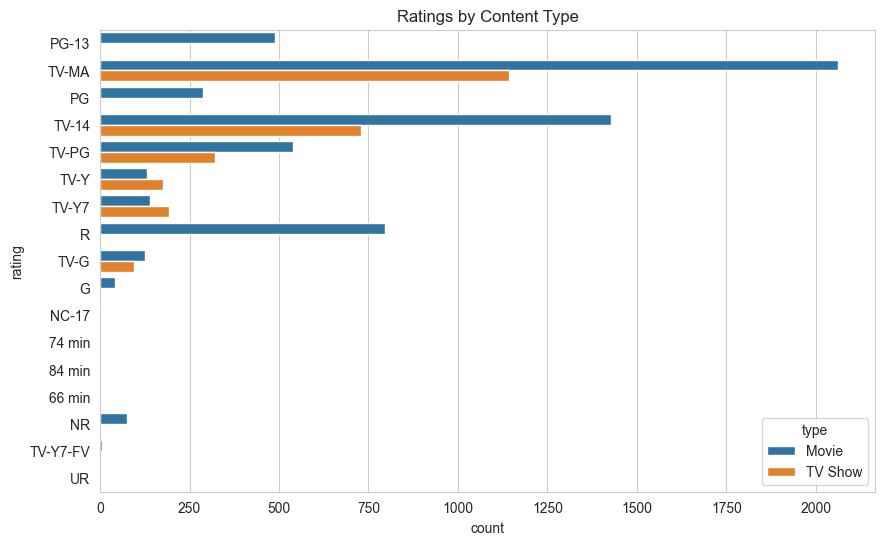

In [31]:
#Rating vs Content Type
plt.figure(figsize=(10,6))
sns.countplot(y='rating', hue='type', data=df)
plt.title("Ratings by Content Type")
plt.show()

# 6. Visualization

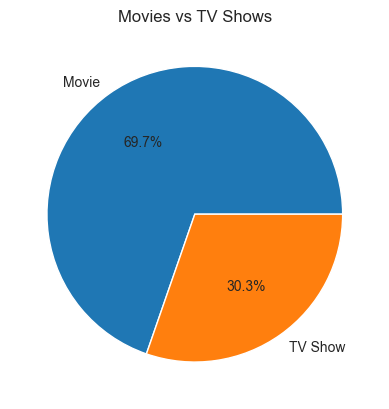

In [32]:
#Content Type Distribution
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Movies vs TV Shows")
plt.ylabel("")
plt.show()

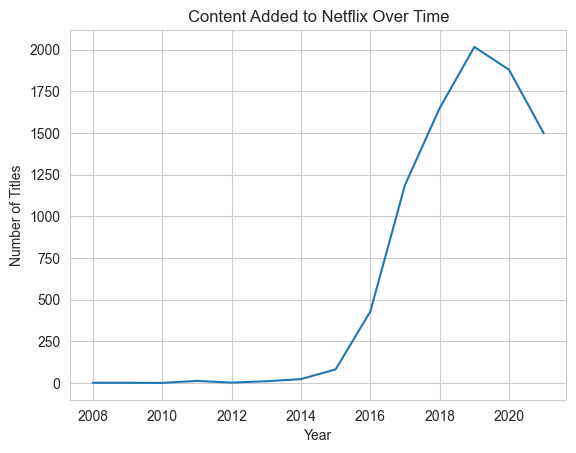

In [33]:
#Content Added Over Time
df['year_added'].value_counts().sort_index().plot()
plt.title("Content Added to Netflix Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

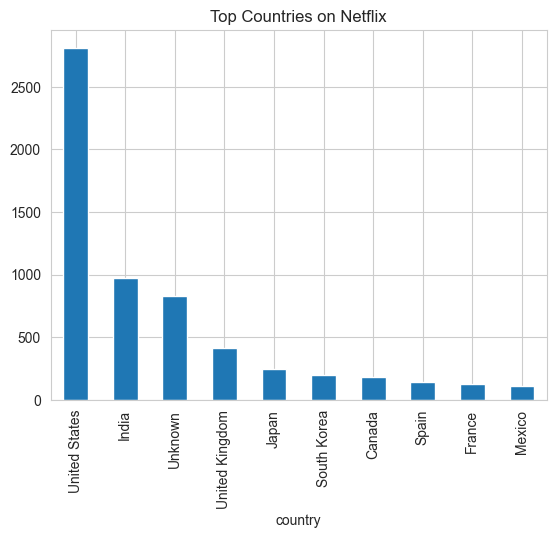

In [34]:
#Top Countries
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries on Netflix")
plt.show()

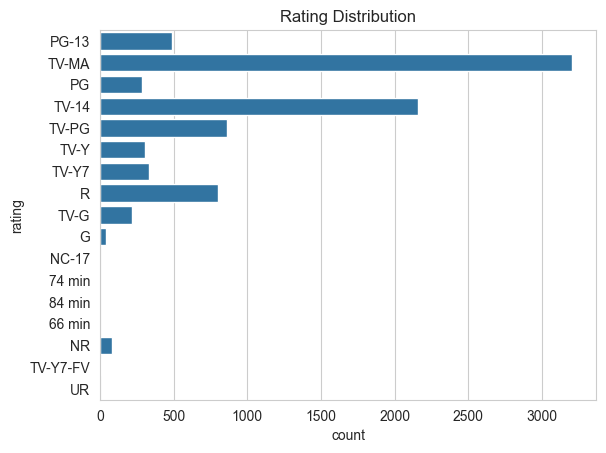

In [35]:
#Rating Distribution
sns.countplot(y='rating', data=df)
plt.title("Rating Distribution")
plt.show()

In [37]:
df['duration_number'] = df['duration'].str.extract('(\d+)')
df['duration_number'] = df['duration_number'].astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\SAURABH ANAND\AppData\Local\Temp\ipykernel_21540\4211511874.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_number'] = df['duration'].str.extract('(\d+)')
